Testing Accuracy : 96.97736540815241

Training Accuracy : 96.99145359055328

            Actual     Predict
376455   46.089237   45.886192
569332   57.277985   56.652794
471106   79.846664   79.321564
525589  106.615845  106.764816
286844  515.750000  512.883423
...            ...         ...
555821   67.404488   70.291702
514183   32.183067   32.159538
195395  371.227844  370.630005
577962   55.439602   55.120396
1092    321.969086  315.374695

[120593 rows x 2 columns]


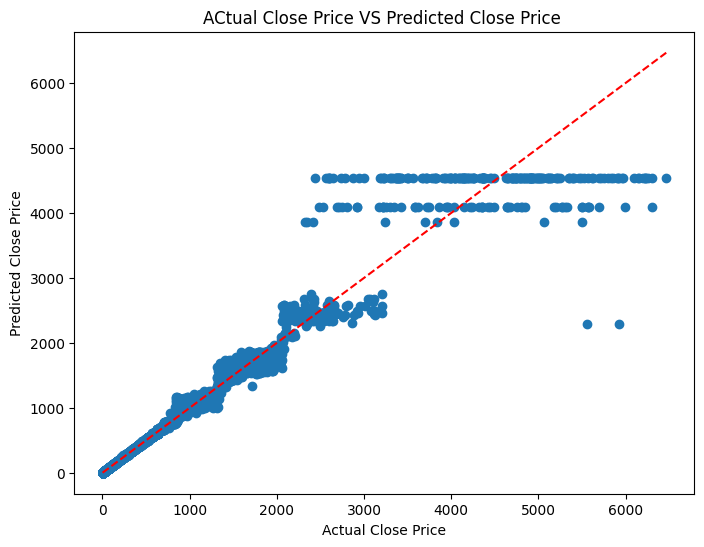

['stock_model.pkl']

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder
from xgboost import XGBRegressor
from sklearn.metrics import accuracy_score
import joblib


data = pd.read_csv(r"C:\Users\Saksham Awasthi\Downloads\stock_details_5_years.csv.zip")
data.drop(columns = ["Date"],inplace = True)

la = LabelEncoder()
la.fit(data["Company"])
data["Company" ] = pd.DataFrame(la.transform(data["Company"]))

x = data[["Open", "High", "Low", "Volume", "Dividends", "Stock Splits", "Company"]]
y = data["Close"]

x_train,x_test, y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 40)

model = XGBRegressor()
model.fit(x_train,y_train)
print("Testing Accuracy :",model.score(x_test,y_test)*100)
print("")
print("Training Accuracy :",model.score(x_train,y_train)*100)
print("")

prd = model.predict(x_test)


result = pd.DataFrame(
    {
        'Actual':y_test,
        'Predict':prd
    }
)
print(result)

plt.figure(figsize = (8,6))
plt.scatter(y_test,prd)

plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("ACtual Close Price VS Predicted Close Price ")

plt.plot(
    
        [y_test.min(),y_test.max()],
        [y_test.min(),y_test.max()],
        'r--'
)

plt.savefig('Actual_VS_Predicted.png',dpi = 300,bbox_inches = 'tight')
plt.show()

joblib.dump(model,'stock_model.pkl')
